# **CESM amip water tracer - spatial dimension focus**
Plot regarding the sptial analysis : time mean plots (map and vertical distribution), 
Focus on the latitude and altitude (pressure) dimensions 

This notebook requires a prior storage of integrated water vapour (cell 22 of Sanity checks notebook)

## **Initial Set Up-related**

### Imports

In [1]:
%matplotlib inline
########## OS Interaction ##########
import os
import sys
import cftime

########## General ##########
import numpy as np
import netCDF4 as nc
import xarray as xr
import scipy as sp
import pandas as pd
import numpy as np
import numpy.ma as ma
import matplotlib.colors as colors 
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import ticker
from matplotlib import gridspec
import dask
import dask.bag as db
from dask.diagnostics import ProgressBar

########## Cartopy+ Shapely ##########
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing
from mpl_toolkits.axes_grid1 import make_axes_locatable


### Function Definitions

In [2]:
# Overall: unstacks time for an input data set
def unstack_time(ds_in):

    # Groups by year or months , calculates the mean, then takes/assigns the resulting values
    years = ds_in.groupby('time.year').mean('time').year
    months = ds_in.groupby('time.month').mean('time').month

    # Makes a pandas MultiIndex that is years x months
    midx = pd.MultiIndex.from_product([years.values,months.values], names=("year","month"))

    # Creates a temporary data set copy from ds_in, multiindex yxm and assign it 
    ds_temp = ds_in.copy()
    ds_temp = ds_temp.assign_coords({'time':midx})
    ds_out = ds_temp.unstack()
    return ds_out

##########

# Overall: creates a vertical integration function accounting for totpography and surface pressure
def vert_int_hybrid(ds, var, ds_hybrid):
    g    = 9.80665   # m/s²
    P0   = 100000.   # Pa  (standard reference pressure)

    q    = ds[var]
    PS   = ds_hybrid['PS']    # surface pressure  (Pa)
    hyai = ds_hybrid['hyai']  # interface A coefficients
    hybi = ds_hybrid['hybi']  # interface B coefficients

    # Interface pressures at every grid point & level interface
    P_i = hyai * P0 + hybi * PS          # shape: (time, ilev, lat, lon)

    # Pressure thickness of each model layer
    dp = P_i.diff(dim='ilev')            # shape: (time, ilev-1, lat, lon)
    dp = dp.transpose("time", "ilev", "lat", "lon")

    # Copy dp into a DataArray that shares 'lev' dim with q
    dp_lev = ds[var].copy() * 0.0
    dp_lev.values = dp.values

    # Hydrostatic column integral: Σ (q·dp) / g
    layer_int = (q * dp_lev) / g
    total_int = layer_int.sum(dim='lev', skipna=True)
    return total_int
    

### Data path and Variable Definitions

In [3]:
# Data Path
data_dir =  '/scratch/st-mlague-1/mlague/data/iCESM/'

# Creates a list of atmospheric variables
atm_vars = ['TS','TREFHT','PRECC', 'LHFLX','PRECL','Q','TMQ','LNDV','NPV', 'NAV', 'EUV', 'EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV', 'SPV'] # PS is added for the vertical integration
static_vars = ['hyai', 'hybi','PS'] # variables for the hybrid integration

# tracer list,and dictionary associating it with a name
tracer_realnames = ['Q','LNDV','NPV', 'NAV', 'EUV','EAV', 'CSAV', 'CAFV','MARV', 'SAV', 'SAFV', 'AUSV', 'SPV']
tracer_shortnames = ['All Land and Oceans','All Land', 'North Pole', 'North America', 'Europe and Northern Africa', 'Eastern Asia', 'Central South America', 'Central Africa', 'Maritime Continent', 'South America', 'South Africa', 'Australia', 'South Pole']
tracer_dict_reversed = dict(zip(tracer_realnames, tracer_shortnames))

# case list, dictionary associating it with a name
case_list = ['icesm_continents_sst'] #case list
short_list=['amip'] # case list names
short_names = dict(zip(case_list, short_list))



### Dictionary Definitions

In [4]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric variables
ts_dict_atm = {}

for case in case_list:
    # Defines the time series directory name for the case
    ts_dir = Path(data_dir) / case / 'TimeSeries'

    # Build the list of atm files with pathlib,
    file_list_atm = []
    ds_static_list = []
    for var in atm_vars:
        file_path = f'{case}.cam.h0.ts.0-end.{var}.nc'
        files = sorted(ts_dir.glob(file_path))

        if not files:
            print(f'oh no, no variables for {var}')
        else:
            for file in files:
                    file_list_atm.append(file)
        print( 'got the data from', var) 
        
    # static variables for the integral function
    for var in static_vars:
        file_path = f'{case}.cam.h0.ts.0-end.{var}.nc'
        files = sorted(ts_dir.glob(file_path))
        if not files:
            print(f'oh no, no file for {var}')
        else:
            ds_static_list.append(xr.open_dataset(files[0], engine='netcdf4'))  # ONE file, ONE var
        print('got the data from', var)
        
    # Open the variables all at once without dropping any years
    #with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ds_temp_atm = xr.open_mfdataset(file_list_atm, engine='netcdf4', compat='override',chunks={'time': 36, 'lev': 30, 'lat': 48, 'lon': 72} )
    ds_temp_atm_short = ds_temp_atm.isel(time=slice(11,323)) # Drops the first year
    ds_temp_static = xr.merge(ds_static_list)
    ds_static_coeffs = ds_temp_static[['hyai', 'hybi', 'P0']]
    ds_static_PS = ds_temp_static['PS'].isel(time=slice(11, 323))
    # Merge everything
    ds_temp_atm_short = xr.merge([ds_temp_atm_short, ds_static_coeffs, ds_static_PS], join='override')

    print('data put together and cut!')
    short = short_names[case]
    ds_temp_atm_short.attrs['title'] = short  # assign the short name as the title
    ts_dict_atm[short] = ds_temp_atm_short.copy()
    del ds_temp_atm, ds_temp_atm_short  # Deletes the temporary data sets

got the data from TS
got the data from TREFHT
got the data from PRECC
got the data from LHFLX
got the data from PRECL
got the data from Q
got the data from TMQ
got the data from LNDV
got the data from NPV
got the data from NAV
got the data from EUV
got the data from EAV
got the data from CSAV
got the data from CAFV
got the data from MARV
got the data from SAV
got the data from SAFV
got the data from AUSV
got the data from SPV
got the data from hyai
got the data from hybi
got the data from PS
data put together and cut!


### Weighting 

In [5]:
# Weights the latitude, renames it to "weights"
weights = np.cos(np.deg2rad(ts_dict_atm['amip']['TS'].lat))
weights.name = "weights"

## **Data Analysis-related**

### Spatial (map and cross section)

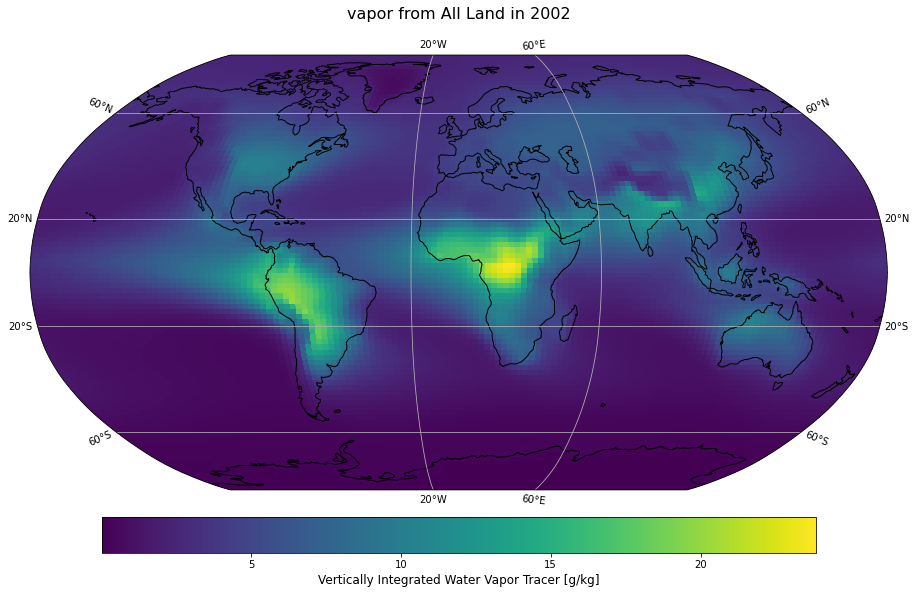

In [26]:
## Robinson map plot of vertically integrated water vapour in 1985 only 1 tracer, 1 year
case = 'amip'
tracer = 'LNDV'
year_select = [2002]

# Create the Robinson map figure
fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(1,1,1, projection=ccrs.Robinson())

for year in year_select :
    data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc") # vertical integration after several years
    data_year = data_integrated.mean('time') #mean over the chosen year

    data_plot, lon_plot = add_cyclic_point(data_year.values, coord=data_year.lon.values) # Add cyclic point to avoid the white line

    # Plot the data and add coastlines, gridlines colorbar and tittle
    pc = ax.pcolormesh(lon_plot, data_year.lat.values, data_plot,transform=ccrs.PlateCarree(), 
                           cmap='viridis',shading='auto')
    ax.coastlines()
    ax.gridlines(draw_labels=True,xlocs=[ -20, 60 ],ylocs=[-60, -20, 20, 60])
    cbar = plt.colorbar(pc, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cbar.set_label('Vertically Integrated Water Vapor Tracer [g/kg]', fontsize=12)
    ax.set_title(f'vapor from {tracer_dict_reversed[tracer]} in {year}', fontsize=16, pad=20)

plt.show()
plt.close(fig)

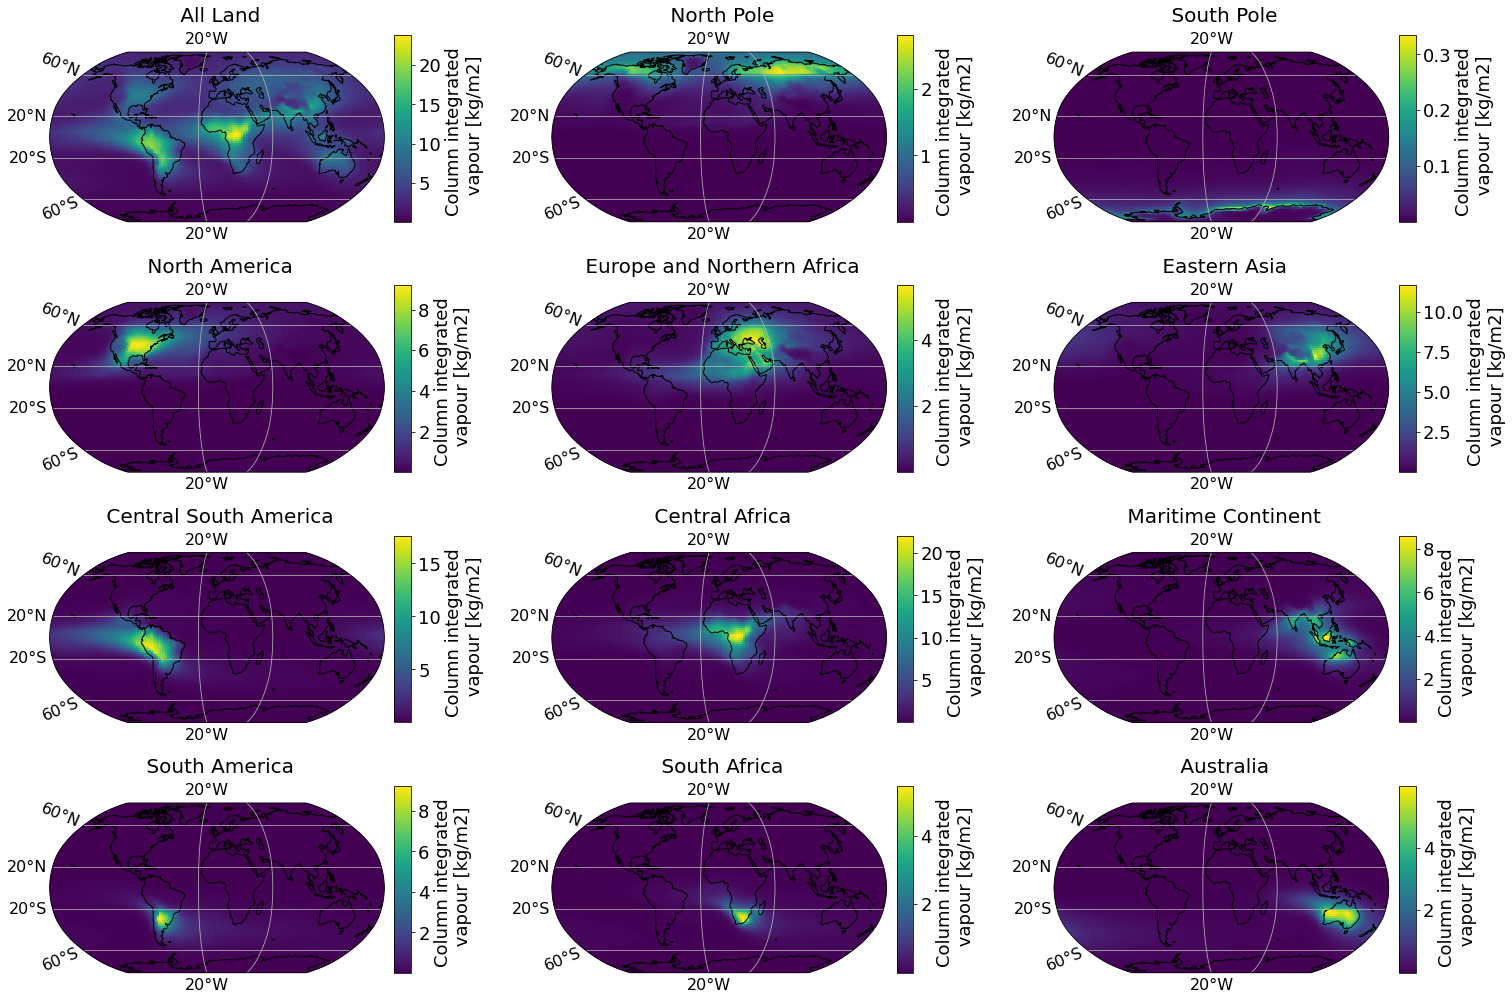

In [44]:
## Robinson map time mean for every tracer 
case = 'amip'
tracer_list = ['LNDV','NPV','SPV', 'NAV', 'EUV','EAV', 'CSAV', 'CAFV','MARV', 'SAV', 'SAFV', 'AUSV']
# Create a 4x3 figure with individual colorbars
fig = plt.figure(figsize=(24, 18))
gs = fig.add_gridspec(4, 3, hspace=0.1, wspace = 0.5)
ax_list = [fig.add_subplot(gs[i // 3, i % 3], projection=ccrs.Robinson()) for i in range(12)]
for i, tracer in enumerate(tracer_list):   
    ax = ax_list[i]
    data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc") # vertical integration 
    data_year = data_integrated.mean(dim ='time') #mean over the year
    data_plot, lon_plot = add_cyclic_point(data_year.values, coord=data_year.lon.values)   # Add cyclic point to avoid the white line and plot data
    figure = ax.pcolormesh(lon_plot, data_year.lat.values, data_plot,transform=ccrs.PlateCarree(), cmap='viridis',shading='auto')
    
    #addfigure title,  colobar  and its title, coastlines and gridlines 
    ax.set_title(f' {tracer_dict_reversed[tracer]}', fontsize=20, pad=10) 
    cax = ax.inset_axes([1.03, 0., 0.05, 1.1])  # [x, y, width, height] in axis fractio for the individual cb
    cb = fig.colorbar(figure, cax=cax) # cb 
    cb.set_label('Column integrated \n vapour [kg/m2]', fontsize=18)
    cb.ax.tick_params(labelsize=18 )
    ax.coastlines()
    gl = ax.gridlines(draw_labels=True,xlocs=[ -20, 60 ],ylocs=[-60, -20, 20, 60])
    gl.right_labels = False
    gl.xlabel_style = {'size': 16}
    gl.ylabel_style = {'size': 16}
    
#fig.suptitle('all the tracer vertically intergrated water vapor mean in time ', fontsize=20, y=0.91)
plt.show()

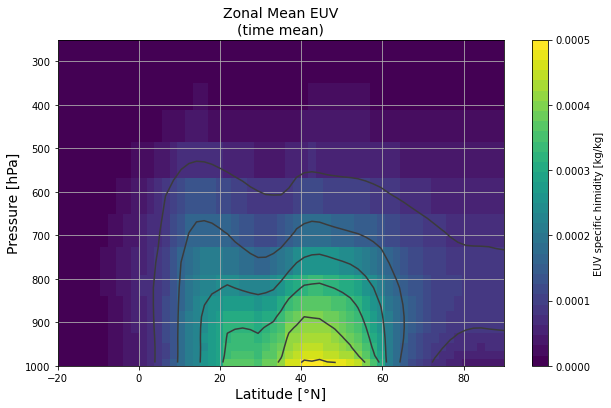

In [43]:
#Overall : Howmöller plots : quick script with a single plot to check a precise tracer concentration 
#depending on latitude and pressure 

case = 'amip'
tracer = 'EUV'  # change this to any tracer you want
tracer_zonal_mean = ts_dict_atm[case][tracer].mean(dim='lon') # shape: (time, lev, lat)
mean = tracer_zonal_mean.mean(dim='time')  # shape (lev, lat)
latitude,pressure= np.meshgrid(mean.lat.values, mean.lev.values) # data for the plots

plt.figure(figsize=(10, 6))
clim = [0, 5e-4]
#plot with colormesh
pc = plt.pcolormesh( latitude,pressure, mean.values, cmap=plt.cm.get_cmap('viridis', 32),vmin=clim[0], vmax=clim[1], shading='auto')
ct = plt.contour(latitude, pressure, mean.values,colors=[[0.23, 0.23, 0.23]]) 

# layout :plot title, colorbar title, axis labels and limits, grid
plt.title('Zonal Mean %s\n(time mean)' % tracer, fontsize=14)
plt.colorbar(pc, label='%s specific himidity [kg/kg]' % tracer)
plt.ylim([1000, 250]) # Pressure decreasing from left to right
plt.xlim([-20, 90])   # Latitude
#plt.gca().invert_xaxis()
plt.ylabel('Pressure [hPa]', fontsize=14)
plt.xlabel('Latitude [°N]', fontsize=14)

plt.grid()
plt.show()
plt.close()

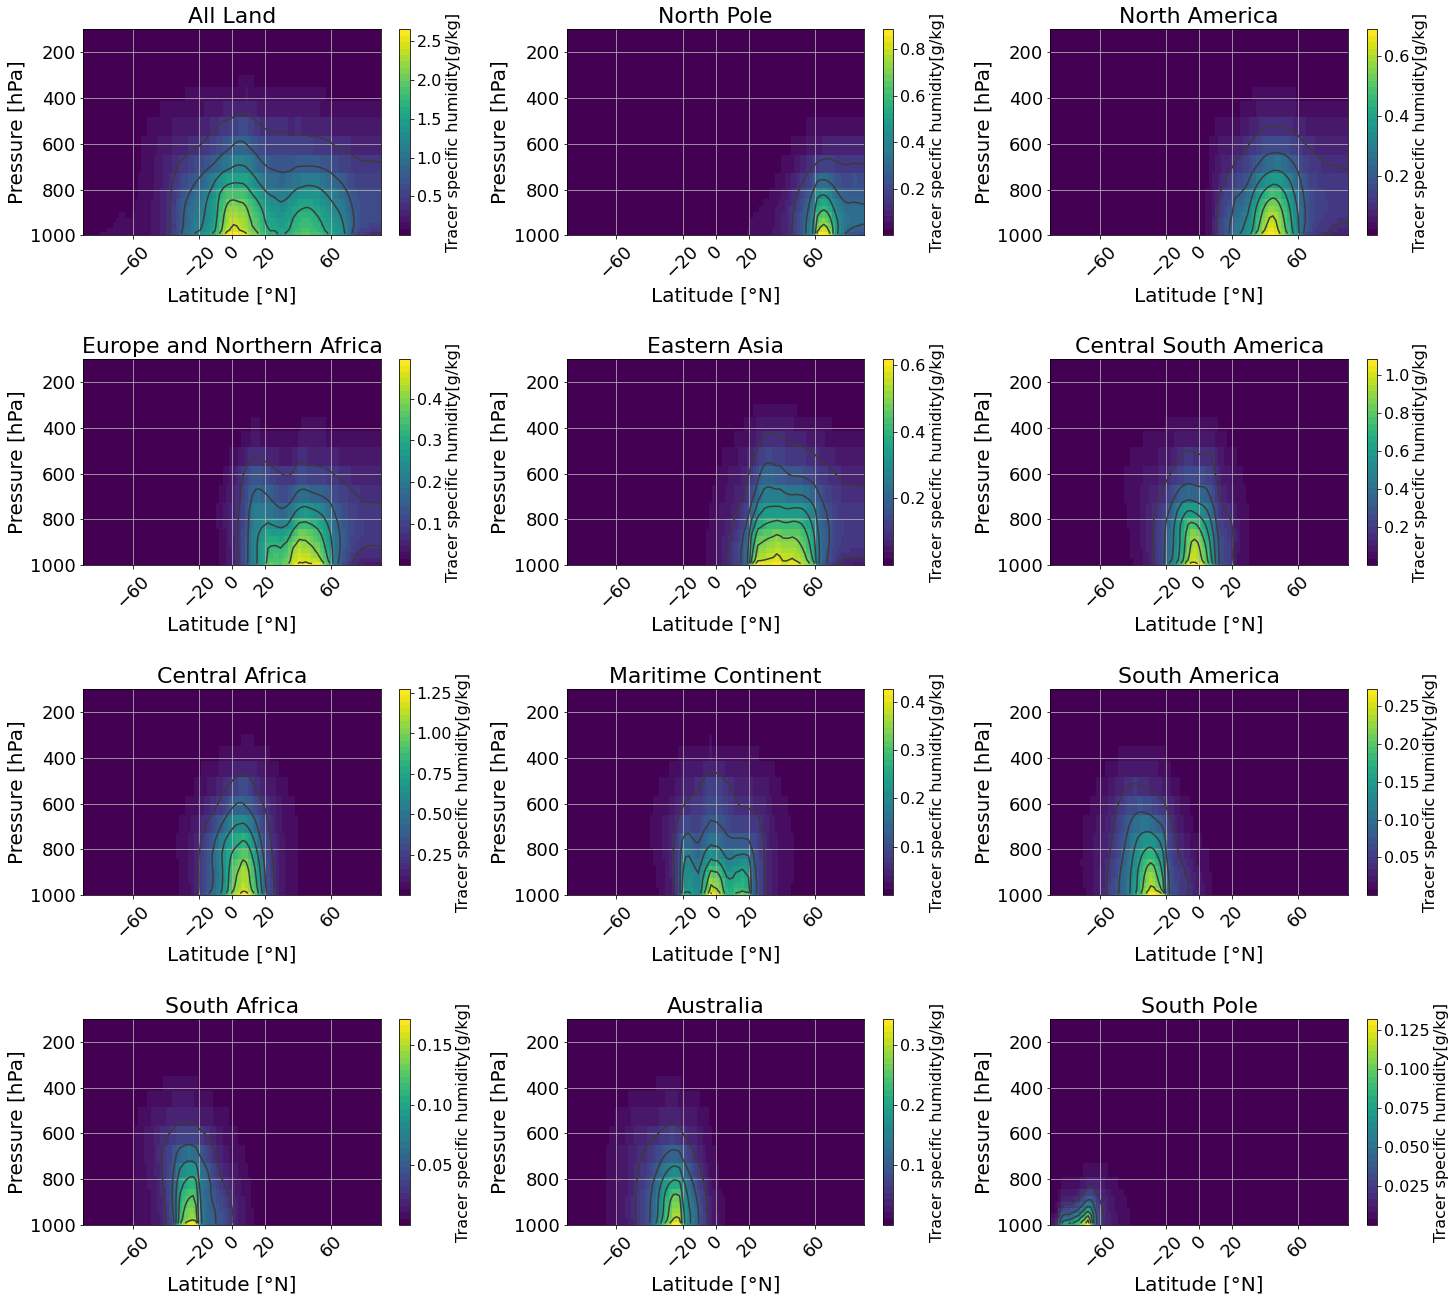

In [17]:
#Overall : cross section : all tracer concentration depending on latitude and pressure 
case = 'amip'
tracer_list = ['LNDV','NPV', 'NAV', 'EUV','EAV', 'CSAV', 'CAFV','MARV', 'SAV', 'SAFV', 'AUSV', 'SPV']
#general figure layout
fig = plt.figure(figsize=(24, 22))
gs = fig.add_gridspec(4, 3,wspace=0.3, hspace=0.6)
ax_list = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(12)]
pc =None
for i, tracer in enumerate(tracer_list):
    ax = ax_list[i]
    #print (case, tracer)
    tracer_zonal_mean = ts_dict_atm[case][tracer].mean(dim='lon') # shape: (time, lev, lat)
    mean = tracer_zonal_mean.mean(dim='time')*1000  # shape (lev, lat)
    latitude,pressure= np.meshgrid(mean.lat.values, mean.lev.values)
    
    pc = ax.pcolormesh( latitude,pressure, mean.values, cmap=plt.cm.get_cmap('viridis', 32), shading='auto')
    ct = ax.contour(latitude, pressure, mean.values,colors=[[0.23, 0.23, 0.23]]) 
    ax.set_title(tracer_dict_reversed[tracer], fontsize=22)
    ax.set_ylabel('Pressure [hPa]', fontsize=20)
    ax.set_xlabel('Latitude [°N]', fontsize=20)
    ax.set_ylim([1000, 100]) # Pressure decreasing from left to right
    ax.set_xlim([-90, 90])   # Latitude
    ax.set_xticks([-60, -20, 0, 20, 60])
    ax.tick_params(axis='x',labelsize=18, labelrotation=45)
    ax.tick_params(axis='y',labelsize=18)
    ax.grid()
    cb = fig.colorbar(pc, ax=ax, orientation='vertical')
    cb.set_label('Tracer specific humidity[g/kg]',fontsize=16)
    cb.ax.tick_params(labelsize=16)

#plt.gca().invert_xaxis()
#fig.suptitle('spatial cross section plots ', fontsize=20, y=0.95)
plt.show()

### Pressure focus Plots

#### Cross section (pressure x time)

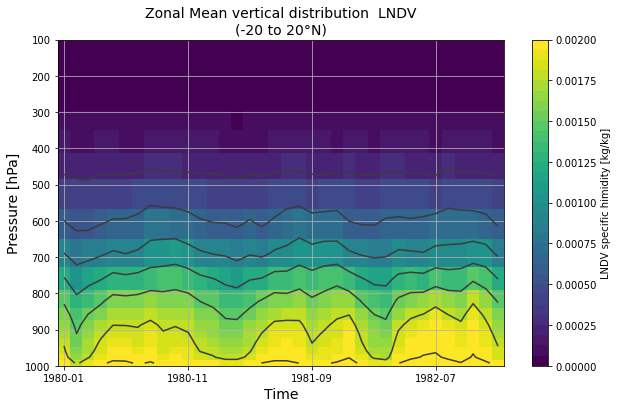

In [6]:
#Overall :cross-section plots :depending on time and pressure (latitude weighted mean)
#Quick script with a single plot focus on a  tracer  (possibility to focus on a latitude slice)

case = 'amip'
tracer = 'LNDV'  # change this to any tracer you want

tracer_zonal_mean = ts_dict_atm[case][tracer].mean(dim='lon') # shape: (time, lev, lat)
#if you want for all latitude, replace -20, 20 by -90,90
mean = tracer_zonal_mean.sel(lat=slice(-20, 20)).weighted(weights).mean('lat') # shape (lev, lat) 
mean = mean.isel(time=slice(36)) # line to have only 3 years, delete it to have the total time lenght
pressure, time = np.meshgrid( mean.lev.values, mean.time.values,)  # data for the plots

plt.figure(figsize=(10, 6))
clim = [0, 2e-3]  # colorscale limit

# plot with colormesh
pc = plt.pcolormesh( time ,pressure, mean.values, cmap=plt.cm.get_cmap('viridis', 32),vmin=clim[0], vmax=clim[1], shading='auto')
ct = plt.contour(time, pressure, mean.values,colors=[[0.23, 0.23, 0.23]]) 

# layout :plot title, colorbar title, axis labels and limits, grid
plt.title('Zonal Mean vertical distribution ' % tracer, fontsize=14)
plt.colorbar(pc, label='%s specific himidity [kg/kg]' % tracer)
plt.ylim([1000, 100]) # Pressure decreasing from left to right
#plt.xlim([-90, 90])   # Latitude limit
plt.ylabel('Pressure [hPa]', fontsize=14)
plt.xlabel('Time', fontsize=14)
plt.grid()

plt.show()
plt.close()

#### Line (and stackline) plots

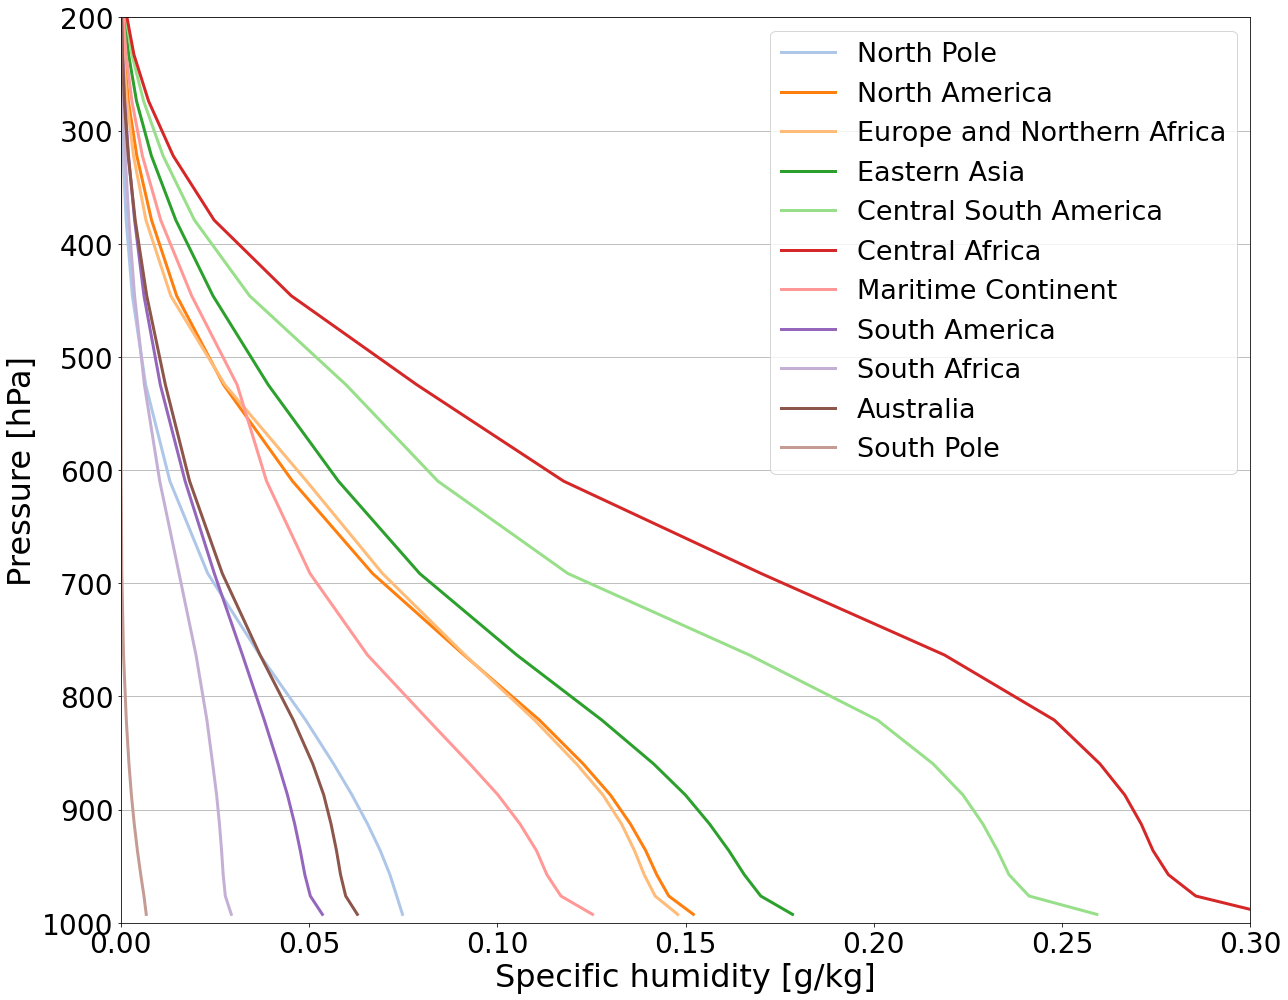

In [11]:
# for a chosen year : distribution of vertically integrated vapor over latitude
case = 'amip'
tracer_list = ['NPV','NAV', 'EUV','EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV','SPV']

plt.figure(figsize=(18, 14))

all_levs = None
colors = plt.cm.tab20.colors 

for i,tracer in enumerate(tracer_list):
    tracer_zm = ts_dict_atm[case][tracer].mean('lon')#shape :(lat, time, lev)
    tracer_ts = tracer_zm.mean('time') # shape: (lat, lev)
    tracer_lev= tracer_ts.weighted(weights).mean(dim='lat')*1000 # data shape: ( lev)
    all_levs = tracer_ts.lev.values # level dimension 
    
    tracer_pct = (tracer_lev / tracer_lev.sum()) * 100 # turn data  into percentage
    #plot either tracer_lev or tracer_pct depending on if you want the date of the partition
    plt.plot( tracer_lev,all_levs,color=colors[i+1 % len(colors)],label=tracer_dict_reversed[tracer],linewidth=3) 

#layout : axis limits and labels, title, grid
plt.ylim(1000,200)
plt.xlim(0,3e-1)
plt.ylabel('Pressure [hPa]', fontsize=32)
plt.xlabel('Specific humidity [g/kg]', fontsize=32)
#plt.title(f'Altitude distribution of all tracers specific humidity \n(time and zonal mean)', fontsize=18)
plt.grid(axis='y')
plt.legend(fontsize=27) #lengend 
plt.tick_params(axis='both', labelsize=28)#frontsize of axis scale

plt.tight_layout()
plt.show()
plt.close()

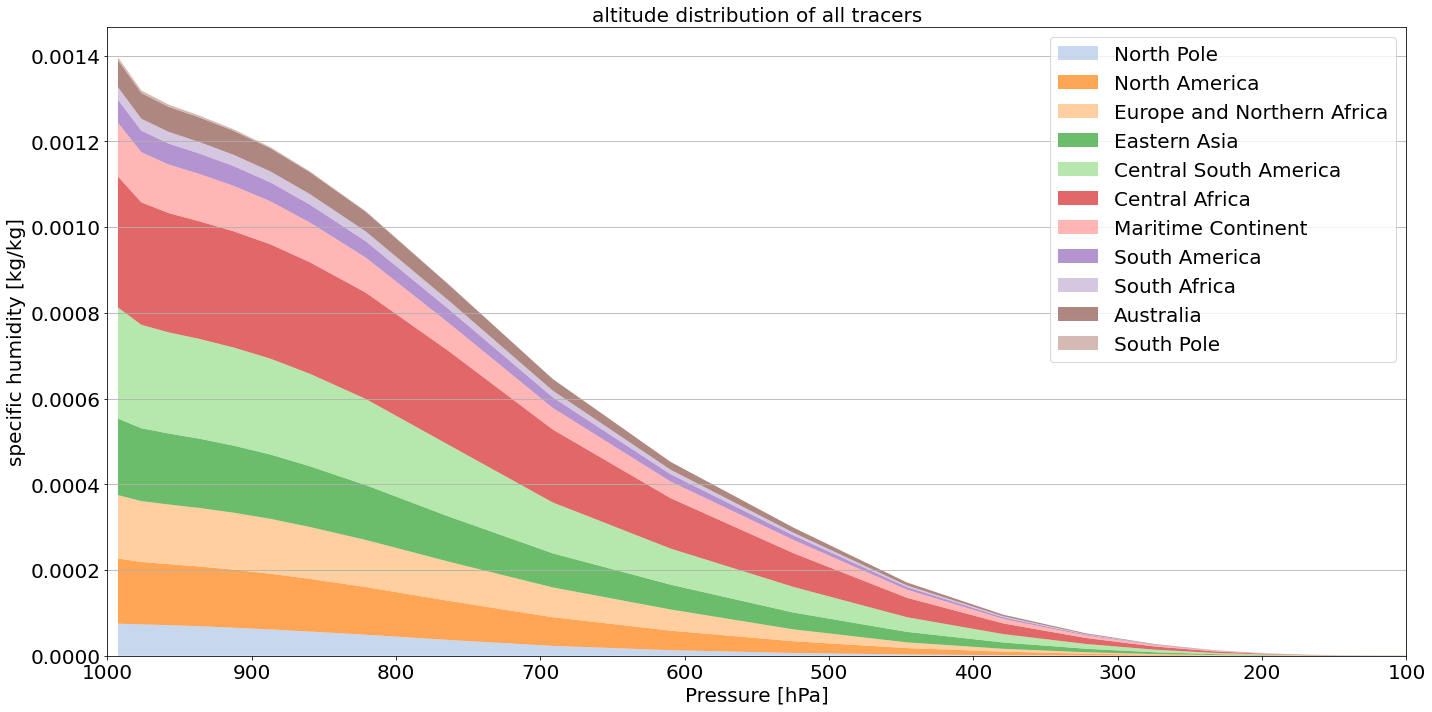

In [38]:
# for a chosen year : distribution of specific humidity vapor over altitude
case = 'amip'
tracer_list = ['NPV','NAV', 'EUV','EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV','SPV']

plt.figure(figsize=(20, 10))

all_lats = None
all_values = []

for tracer in tracer_list:
    tracer_zm = ts_dict_atm[case][tracer].mean('lon')#shape :(lat, time, lev)
    tracer_ts = tracer_zm.mean('time') # shape: (lat, lev)
    tracer_lev= tracer_ts.weighted(weights).mean(dim='lat')# shape: , lev)
    all_values.append(tracer_lev.values)#store the new value each time to stack later
all_levs = tracer_ts.lev.values  # level dimension 

# Stack et area plot
labels = [tracer_dict_reversed[t] for t in tracer_list]
colors = [plt.cm.tab20.colors[i % 20] for i in range(1,len(tracer_list)+1)]
plt.stackplot(all_levs, all_values, labels=labels,colors=colors, alpha=0.7)

#layout : axis limits and labels, title, grid
plt.xlim(1000,100)
#plt.ylim(0,9)
plt.xlabel('Pressure [hPa]', fontsize=20)
plt.ylabel('specific humidity [kg/kg]', fontsize=20)
plt.title(f'altitude distribution of all tracers', fontsize=20)
plt.tick_params(axis='both',labelsize=20)
plt.grid(axis='y')
plt.legend(fontsize=20)

plt.tight_layout()
plt.show()
plt.close()

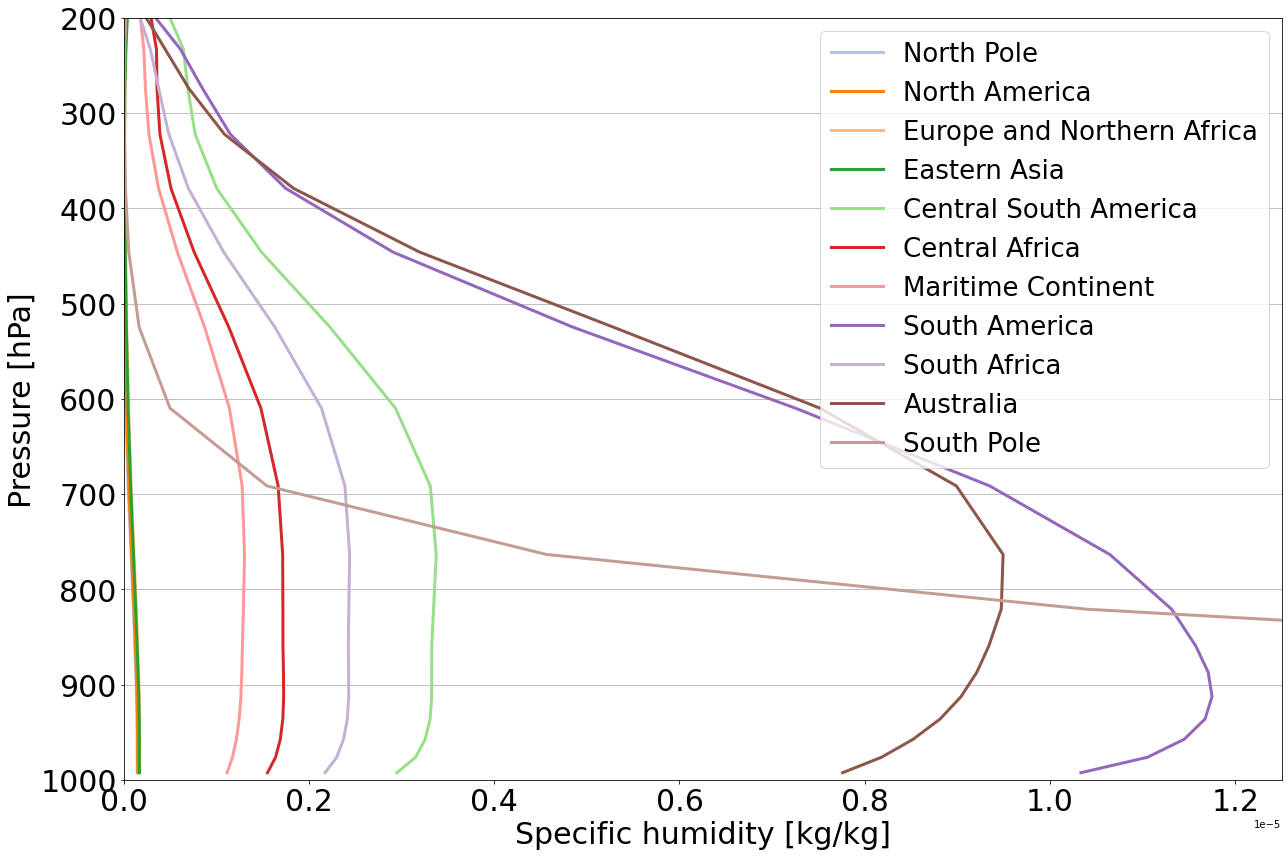

In [19]:
#overall : line plot pressure distribution  of different tracers in the South pole region
case = 'amip'
tracer_list = ['NPV','NAV', 'EUV','EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV','SPV']

plt.figure(figsize=(18, 12))

all_levs = None
colors = plt.cm.tab20.colors 

for i,tracer in enumerate(tracer_list):
    tracer_zm = ts_dict_atm[case][tracer].mean('lon')#shape :(lat, time, lev)
    tracer_ts = tracer_zm.mean('time') # shape: (lat, lev)
    tracer_lev= tracer_ts.sel(lat=slice(-90,-60)).weighted(weights).mean(dim='lat')# shape: (lev)
    all_levs = tracer_ts.lev.values # level dimension 
    plt.plot(tracer_lev, all_levs,color=colors[i+1 % len(colors)],label=tracer_dict_reversed[tracer],linewidth=3)#plot
    
#layout : axis  labels, title, grid
plt.ylim(1000,200)
plt.xlim(0,1.25e-5)
plt.ylabel('Pressure [hPa]', fontsize=30)
plt.xlabel('Specific humidity [kg/kg]', fontsize=30)
#plt.title(f'Altitude distribution of all tracers in the Antartic  (60 to  90 °S)', fontsize=20)
plt.tick_params(axis='both', labelsize=30)#frontsize of axis scale

plt.grid(axis='y')
plt.legend(fontsize=26)
plt.tight_layout()
plt.show()
plt.close()

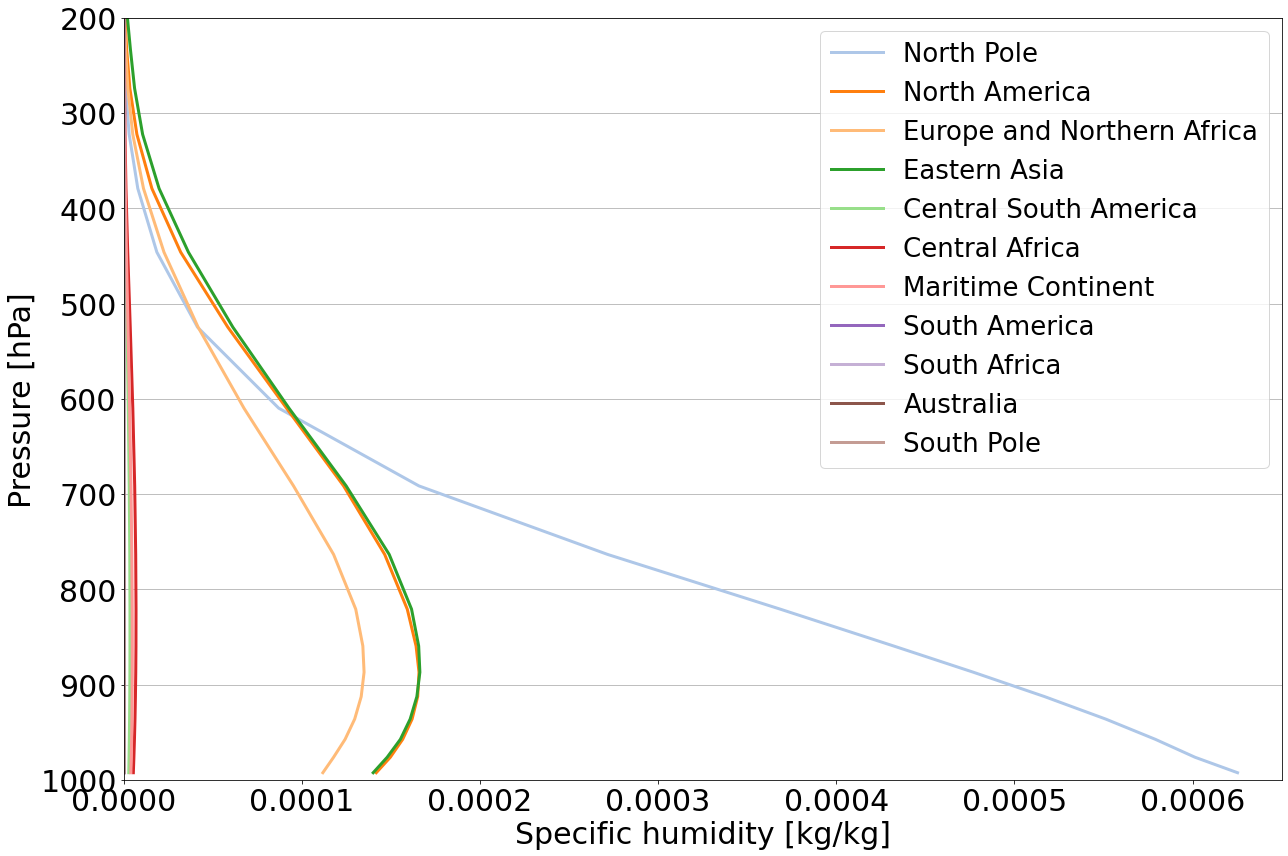

In [6]:
#overall : line plot pressure distribution  of different tracers in the North pole region
case = 'amip'
tracer_list = ['NPV','NAV', 'EUV','EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV','SPV']

plt.figure(figsize=(18, 12))

all_levs = None
colors = plt.cm.tab20.colors 

for i,tracer in enumerate(tracer_list):
    tracer_zm = ts_dict_atm[case][tracer].mean('lon')#shape :(lat, time, lev)
    tracer_ts = tracer_zm.mean('time') # shape: (lat, lev)
    tracer_lev= tracer_ts.sel(lat=slice(60,90)).weighted(weights).mean(dim='lat')# shape: (lev)
    all_levs = tracer_ts.lev.values # level dimension 
    
    plt.plot(tracer_lev, all_levs,color=colors[i+1 % len(colors)],label=tracer_dict_reversed[tracer],linewidth=3) # plot
    
#layout : axis limits and labels, title, grid
plt.ylim(1000,200)
plt.xlim(0,6.5e-4)
plt.ylabel('Pressure [hPa]', fontsize=30)
plt.xlabel('Specific humidity [kg/kg]', fontsize=30)
#plt.title(f'Altitude distribution of all tracers in the Arctic  ( 60 to  90 °N)', fontsize=20)
plt.grid(axis='y')
plt.tick_params(axis='both', labelsize=30)#frontsize of axis scale

plt.legend(fontsize=26)
plt.tight_layout()
plt.show()
plt.close()

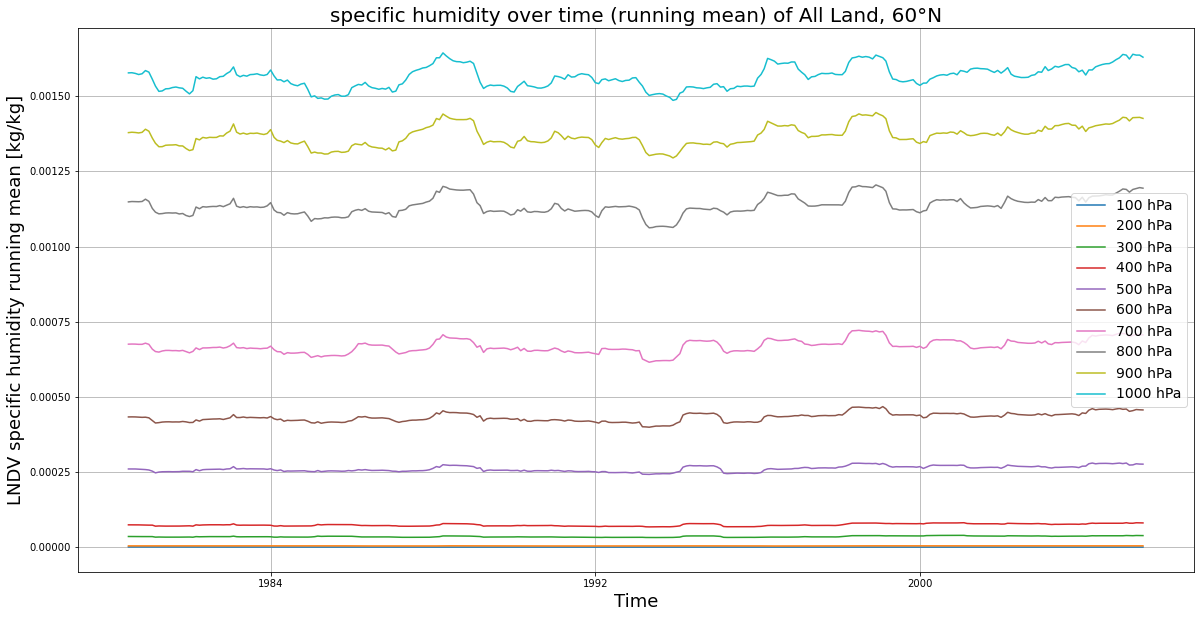

In [12]:
# overall : line plot : for a different  altitudes, specific humidity over time for 1 tracer (specific latitude)
case = 'amip'
tracer = 'LNDV'  # change this to any tracer you want
lat_deg = 60    # latitude of interest [degrees]
lev_hpa = [i*100 for i in range(1,11)] 
#humidity_limit = 1e-3

plt.figure(figsize = (20,10))
tracer_zm = ts_dict_atm[case][tracer].mean(dim='lon')   # shape: (lev, lat, time,)
for lev in lev_hpa:
    tracer_ts = tracer_zm.sel(lev=lev, lat=lat_deg, method='nearest')  # shape: (time,), for a specific altitude and latitude
    tracer_run_mean = tracer_ts.rolling( time = 12, center=True ).mean() #12 months running mean
    plt.plot(tracer_run_mean.time.values, tracer_run_mean.values, label = f'{lev} hPa') # plot

    #layout : axis  labels, title
    plt.xlabel('Time', fontsize=18)
    plt.ylabel('%s specific humidity running mean [kg/kg]' % tracer, fontsize=18)
    #plt.ylim(0,humidity_limit)
    plt.title('specific humidity over time (running mean) of %s, %d°N' % (tracer_dict_reversed[tracer],lat_deg), fontsize=20)

plt.grid()
plt.legend(fontsize=14,loc='best')
plt.show()
plt.close()

### Latitude focus Plots

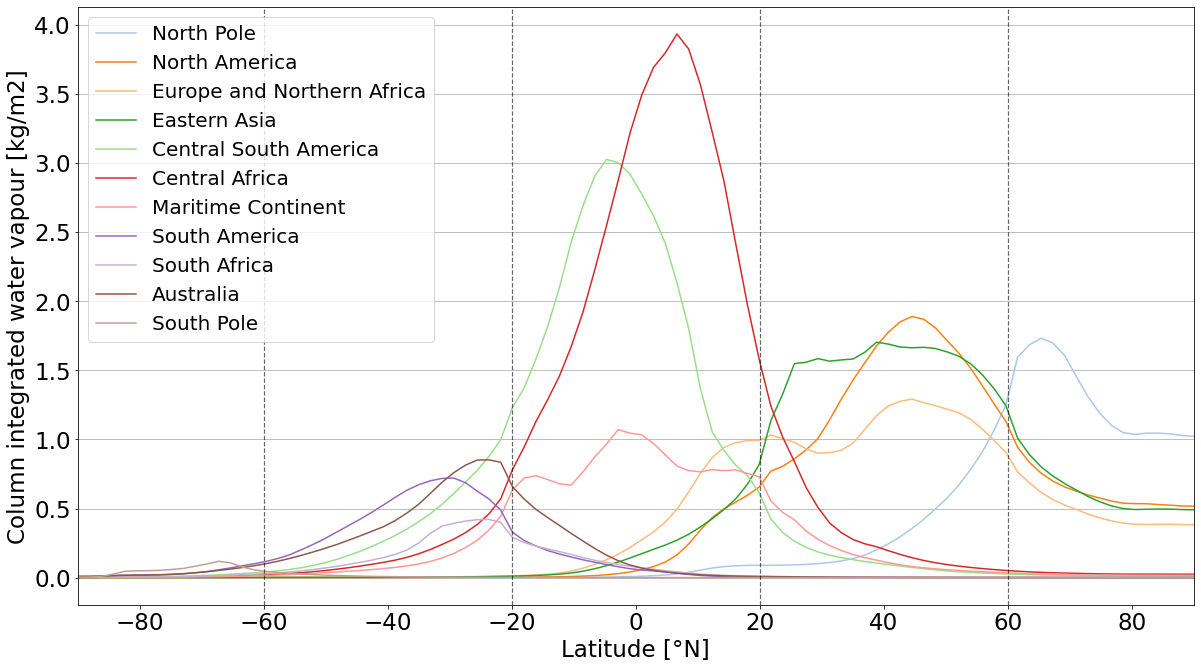

In [7]:
# overall : line plot : for different tracer, vertically integrated  humidity over latitude
case = 'amip'
tracer_list = [ 'NPV','NAV', 'EUV','EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV','SPV']
plt.figure(figsize= (20,11))# overall : line plot : for different tracer, vertically integrated  humidity over latitude
colors = plt.cm.tab20.colors 

for i,tracer in enumerate(tracer_list):
    data_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc") # shape (lon, lev, time)
    data_integrated_year = data_integrated.mean('time') # shape (lon, lev)
    tracer_zm = data_integrated_year.mean(dim='lon') # shape (lev)
    plt.plot(tracer_zm.lat.values, tracer_zm.values, label=tracer_dict_reversed[tracer], color=colors[i+1 % len(colors)])#plot
    
    # layout : axis and title
    plt.xlabel('Latitude [°N]', fontsize=23)
    plt.ylabel('Column integrated water vapour [kg/m2]', fontsize=23)
    plt.xlim(-90,90)
    #plt.title(f'latitude distribution of all tracer', fontsize=14)
    plt.tick_params(axis='both', labelsize=23)#frontsize of axis scale

for lat_line in [-60, -20, 20, 60]:
    plt.axvline(x=lat_line, color='black', linewidth=1.2, linestyle='--', alpha=0.6) # lines for interesting latitude   
plt.grid(axis='y')
plt.legend(fontsize=20,loc='best')
plt.show()
plt.close()

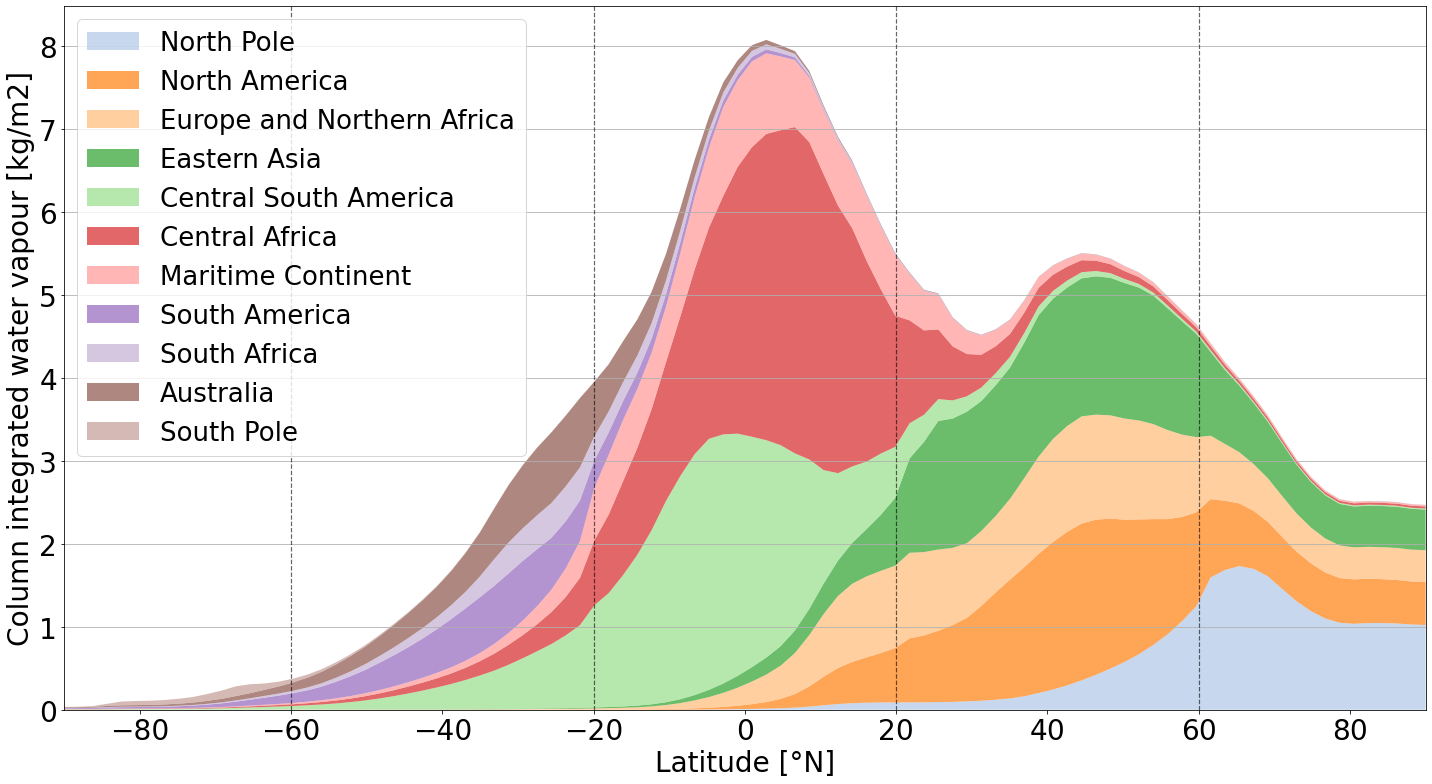

In [8]:
# distribution of vertically integrated vapor over latitude (time mean)
case = 'amip'
tracer_list = ['NPV','NAV', 'EUV','EAV', 'CSAV', 'CAFV', 'MARV', 'SAV', 'SAFV', 'AUSV','SPV']

plt.figure(figsize=(20, 11))

all_lats = None
all_values = []

for tracer in tracer_list:
    tracer_integrated = xr.open_dataarray("vert_int_output/"+tracer+".nc") #shape :(lat, time,lon )
    tracer_zm = tracer_integrated.mean('lon')#shape :(lat, time, )
    tracer_ts = tracer_zm.mean('time') # shape: (lat,)
    all_values.append(tracer_ts.values)#add the new value each time 
all_lats = tracer_ts.lat.values # level dimension 

# Stack et area plot
labels = [tracer_dict_reversed[t] for t in tracer_list]
colors = [plt.cm.tab20.colors[i % 20] for i in range(1,len(tracer_list)+1)]
plt.stackplot(all_lats, all_values, labels=labels,colors =colors, alpha=0.7)

#layout : axis  labels, title, grid
for lat_line in [-60, -20, 20, 60]:
    plt.axvline(x=lat_line, color='black', linewidth=1.2, linestyle='--', alpha=0.6) # lines for interesting latitude
plt.xlim(-90,90)    
#plt.ylim(0,9)
plt.xlabel('Latitude [°N]', fontsize=28)
plt.ylabel('Column integrated water vapour [kg/m2]', fontsize=28)
#plt.title(f'latitude distribution of all tracers', fontsize=20)
plt.tick_params(axis='both', labelsize=28)#frontsize of axis scale

plt.grid(axis='y')
plt.legend(fontsize=26,loc='upper left')
plt.tight_layout()
plt.show()
plt.close()